In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib

In [2]:
data = pd.read_csv("creditcard.csv")
data = data.dropna(subset=["Class"])

X = data.drop("Class", axis=1)
y = data["Class"]

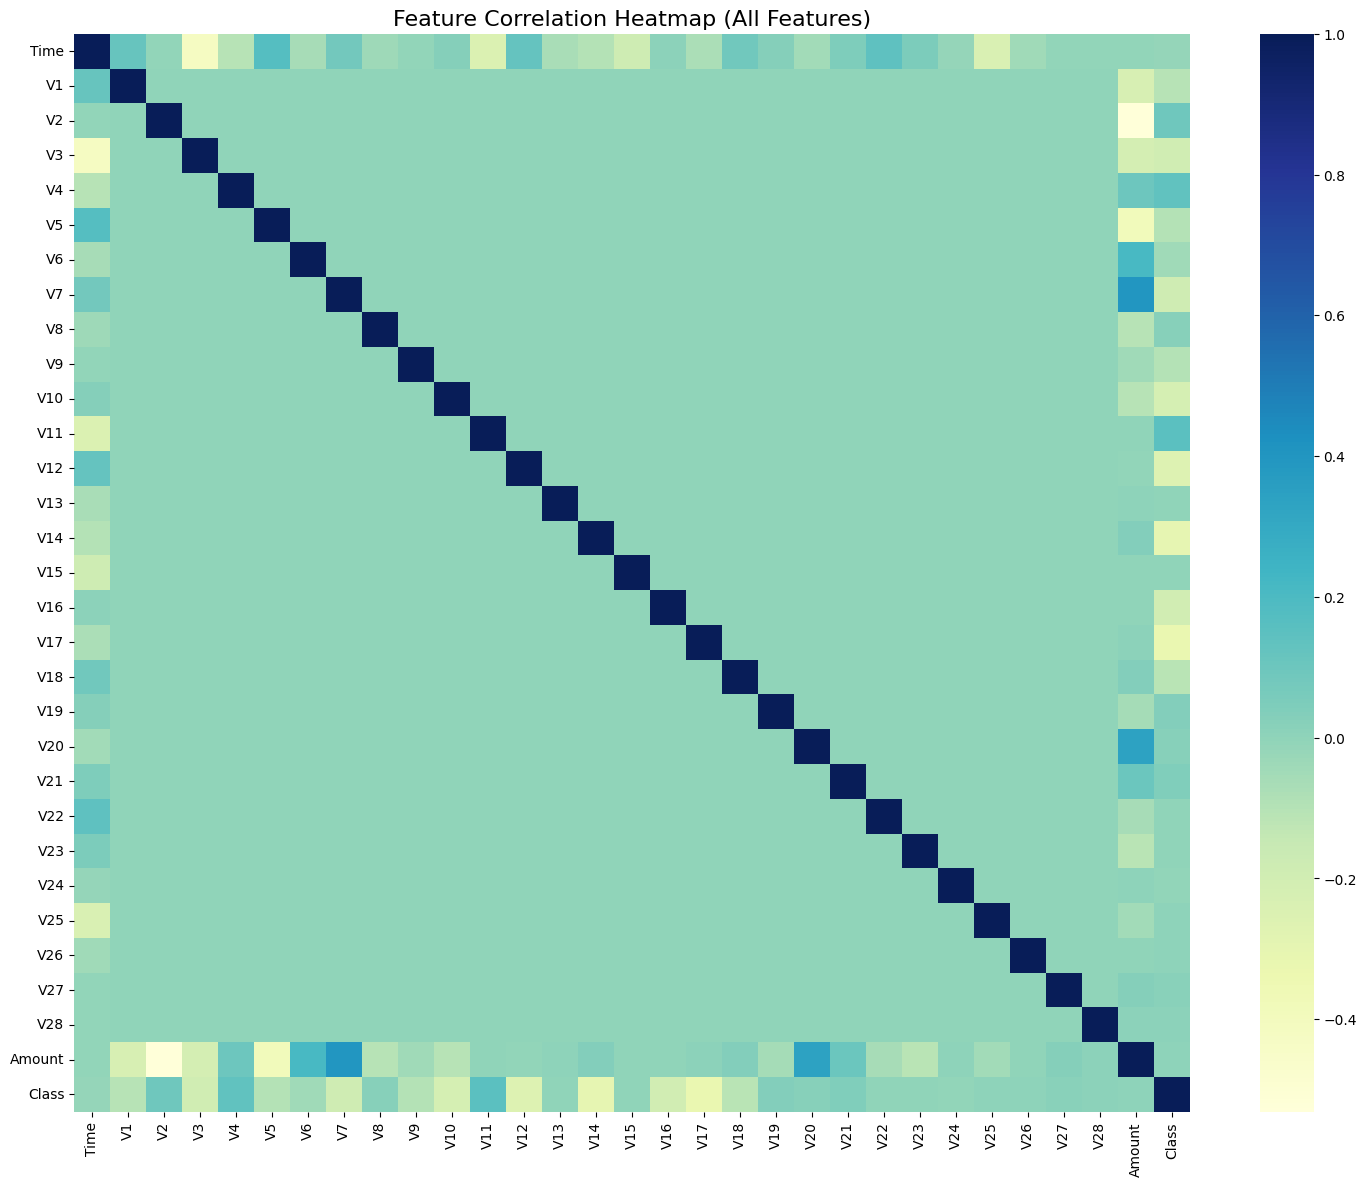

In [3]:
plt.figure(figsize=(18, 14))
corr = data.corr()
sns.heatmap(corr, cmap="YlGnBu", annot=False)
plt.title("Feature Correlation Heatmap (All Features)", fontsize=16)
plt.show()


C:\Users\thath\AppData\Local\Temp\ipykernel_20500\2167348211.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_before.index, y=count_before.values, palette="coolwarm")


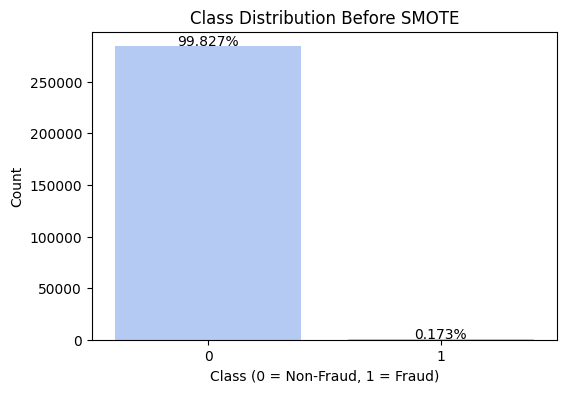

Class distribution before SMOTE:
 Class
0    284315
1       492
Name: count, dtype: int64


In [4]:
plt.figure(figsize=(6,4))
count_before = y.value_counts()
sns.barplot(x=count_before.index, y=count_before.values, palette="coolwarm")
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
for i, val in enumerate(count_before.values):
    plt.text(i, val + 500, f"{(val / len(y))*100:.3f}%", ha='center', fontsize=10)
plt.show()

print("Class distribution before SMOTE:\n", count_before)

C:\Users\thath\AppData\Local\Temp\ipykernel_20500\251557071.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_after.index, y=count_after.values, palette="viridis")


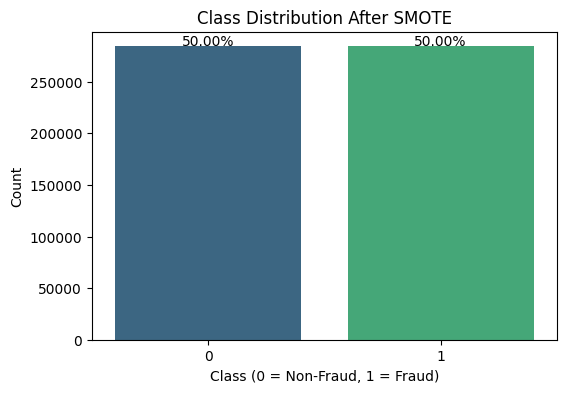


Class distribution after SMOTE:
 Class
0    284315
1    284315
Name: count, dtype: int64


In [5]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

plt.figure(figsize=(6,4))
count_after = y_resampled.value_counts()
sns.barplot(x=count_after.index, y=count_after.values, palette="viridis")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
for i, val in enumerate(count_after.values):
    plt.text(i, val + 500, f"{(val / len(y_resampled))*100:.2f}%", ha='center', fontsize=10)
plt.show()

print("\nClass distribution after SMOTE:\n", count_after)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled
)

In [7]:
xgb_model = XGBClassifier(
    n_estimators=90,
    learning_rate=0.07,
    max_depth=4,
    subsample=0.75,
    colsample_bytree=0.75,
    gamma=0.6,
    reg_lambda=1.2,
    random_state=42,
    eval_metric='logloss',
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.75, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.6,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=90, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
y_pred = xgb_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n XGBoost Model Results:")
print("Accuracy:", round(acc*100,2),"%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


 XGBoost Model Results:
Accuracy: 98.76 %

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     85295
           1       0.99      0.98      0.99     85294

    accuracy                           0.99    170589
   macro avg       0.99      0.99      0.99    170589
weighted avg       0.99      0.99      0.99    170589



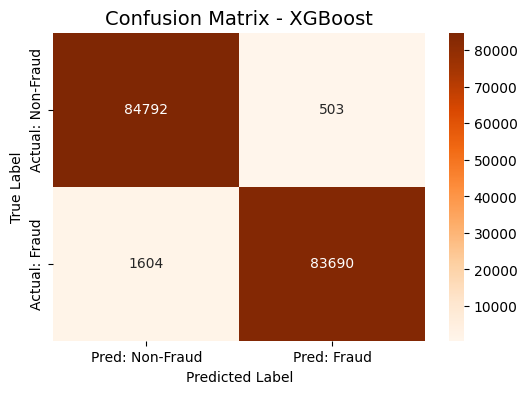

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Pred: Non-Fraud", "Pred: Fraud"],
    yticklabels=["Actual: Non-Fraud", "Actual: Fraud"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost", fontsize=14)
plt.show()

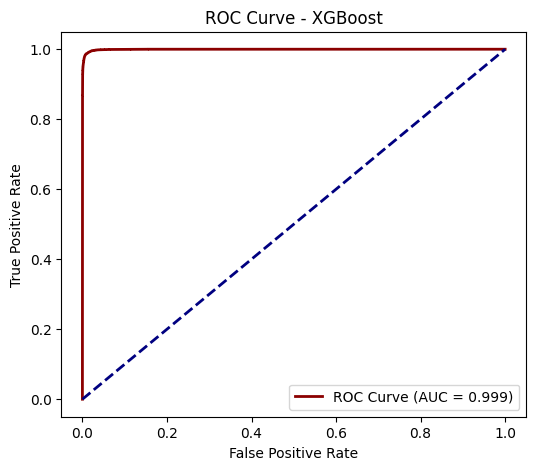

In [10]:
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkred', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.show()

In [11]:
joblib.dump(xgb_model, "xgboost_model.pkl")
print("Model saved as xgboost_model.pkl")

Model saved as xgboost_model.pkl
